In [5]:
#!pip install osmnx
#!pip install OSMPythonTools
#import sys
#!{sys.executable} -m pip install osmnx
# !{sys.executable} -m pip install folium

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import numpy as np
import osmnx as ox
import folium
import mapclassify

parks = gpd.read_file("Parks_(2024).geojson")

In [2]:
parks.head()

,OBJECTID,NAME,OWNER,NOTES,CITY,FEATTYPE,STATUS,SOURCE,SOURCE_YEAR,ShapeSTLength,ShapeSTArea,geometry
0,1,Bob Jones Park,None,None,Southlake,Local Park,Existing,City of Southlake,2021,30037.587797,1.102229e+07,"POLYGON ((-97.13657 32.99702, -97.13731 32.997..."
1,2,Lonesome Dove Park,None,None,Southlake,Local Park,Existing,City of Southlake,2021,2760.737930,3.505679e+05,"POLYGON ((-97.12942 32.97459, -97.12871 32.974..."
2,3,Liberty Park at Sheltonwood,None,None,Southlake,Local Park,Existing,City of Southlake,2021,4120.174030,8.706581e+05,"POLYGON ((-97.14474 32.97113, -97.14425 32.971..."
3,4,Bicentennial Park,None,None,Southlake,Local Park,Existing,City of Southlake,2021,9201.496728,3.494158e+06,"POLYGON ((-97.15109 32.94557, -97.15233 32.945..."
4,5,Royal & Annie Smith Park,None,None,Southlake,Local Park,Existing,City of Southlake,2021,3494.508653,5.710544e+05,"POLYGON ((-97.19851 32.93797, -97.19708 32.937..."


In [3]:
place = "Dallas County, Texas, United States of America"
api = ox.geocoder.geocode_to_gdf(place)

In [4]:
api.explore()

In [5]:
#WAS TRYING TO GET STREET DATA FROM OSM
#kernel keeps dying?
# graph = ox.graph.graph_from_place(place)
# fig, ax = ox.plot.plot_graph(graph, figsize=(6, 6))

In [6]:
#CODE TO UPLOAD DALLAS COUNTY SHAPE DATA (DIDN'T REALIZE ALREADY IN OSM)
#counties = gpd.read_file("Counties.geojson")

#counties.head()

#dallas_ct = counties[counties['COUNTY'] == 'Dallas']
#dallas_ct.head()

#dallas_ct.plot(figsize=(10, 10));

In [7]:
api.head()

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-97.03838 32.54866, -96.8683 32.5474...",-97.038383,32.545349,-96.516882,32.989669,334903154,relation,1837698,32.76204,-96.779007,boundary,administrative,12,0.606079,county,Dallas County,"Dallas County, Texas, United States"


In [8]:
#only grabbing the dallas geometry
dallas_geo = api['geometry'].iloc[0]

In [9]:
#labelling all parks that have some area within Dallas County
parks["in_dallas"] = parks.intersects(dallas_geo)

In [10]:
parks.head()

,OBJECTID,NAME,OWNER,NOTES,CITY,FEATTYPE,STATUS,SOURCE,SOURCE_YEAR,ShapeSTLength,ShapeSTArea,geometry,in_dallas
0,1,Bob Jones Park,None,None,Southlake,Local Park,Existing,City of Southlake,2021,30037.587797,1.102229e+07,"POLYGON ((-97.13657 32.99702, -97.13731 32.997...",False
1,2,Lonesome Dove Park,None,None,Southlake,Local Park,Existing,City of Southlake,2021,2760.737930,3.505679e+05,"POLYGON ((-97.12942 32.97459, -97.12871 32.974...",False
2,3,Liberty Park at Sheltonwood,None,None,Southlake,Local Park,Existing,City of Southlake,2021,4120.174030,8.706581e+05,"POLYGON ((-97.14474 32.97113, -97.14425 32.971...",False
3,4,Bicentennial Park,None,None,Southlake,Local Park,Existing,City of Southlake,2021,9201.496728,3.494158e+06,"POLYGON ((-97.15109 32.94557, -97.15233 32.945...",False
4,5,Royal & Annie Smith Park,None,None,Southlake,Local Park,Existing,City of Southlake,2021,3494.508653,5.710544e+05,"POLYGON ((-97.19851 32.93797, -97.19708 32.937...",False


In [11]:
#grabbing the subset of all parks that are in Dallas County
dal_parks = parks[parks['in_dallas'] == True]

In [12]:
dal_parks.head()

,OBJECTID,NAME,OWNER,NOTES,CITY,FEATTYPE,STATUS,SOURCE,SOURCE_YEAR,ShapeSTLength,ShapeSTArea,geometry,in_dallas
11,12,Twin Star Park,None,E,Rowlett,Local Park,Existing,City of Rowlett,2023,1759.912421,181896.035984,"POLYGON ((-96.52632 32.92398, -96.52576 32.923...",True
12,13,Columbia Park,None,F,Rowlett,Local Park,Proposed,City of Rowlett,2023,1200.661102,84838.762961,"POLYGON ((-96.548 32.91558, -96.54728 32.91557...",True
13,14,Paddle Point/N Lakeside,None,E,Rowlett,Local Park,Existing,City of Rowlett,2023,8033.013397,735614.787512,"MULTIPOLYGON (((-96.53473 32.90103, -96.53489 ...",True
14,15,Kenwood Heights,None,E,Rowlett,Local Park,Existing,City of Rowlett,2023,3385.494851,149958.984225,"POLYGON ((-96.5783 32.9137, -96.5766 32.91222,...",True
15,16,Veterans Memorial Park,None,E,Rowlett,Local Park,Existing,City of Rowlett,2023,882.415201,28145.654443,"POLYGON ((-96.56532 32.90286, -96.56532 32.902...",True


In [13]:
#grabbing all streets that are in Dallas County 
#this took 317 seconds to run (5.5 minutes) 

#we might want to consider excluding paths that are running/walking/pedestrian paths because these are the ones inside the parks typically 
# tags = {"highway": True}

In [14]:
#grabbing only streets tagged as sidewalks (aka walking) 
tags_sidewalk = {
    "footway": "sidewalk",
    "sidewalk": True
}
streets_gdf = ox.features_from_place(place, tags_sidewalk)

In [15]:
#projecting my gdfs to Texas coords
streets_gdf_projected = streets_gdf.to_crs("EPSG:3083")
dal_parks_projected = dal_parks.to_crs("EPSG:3083")

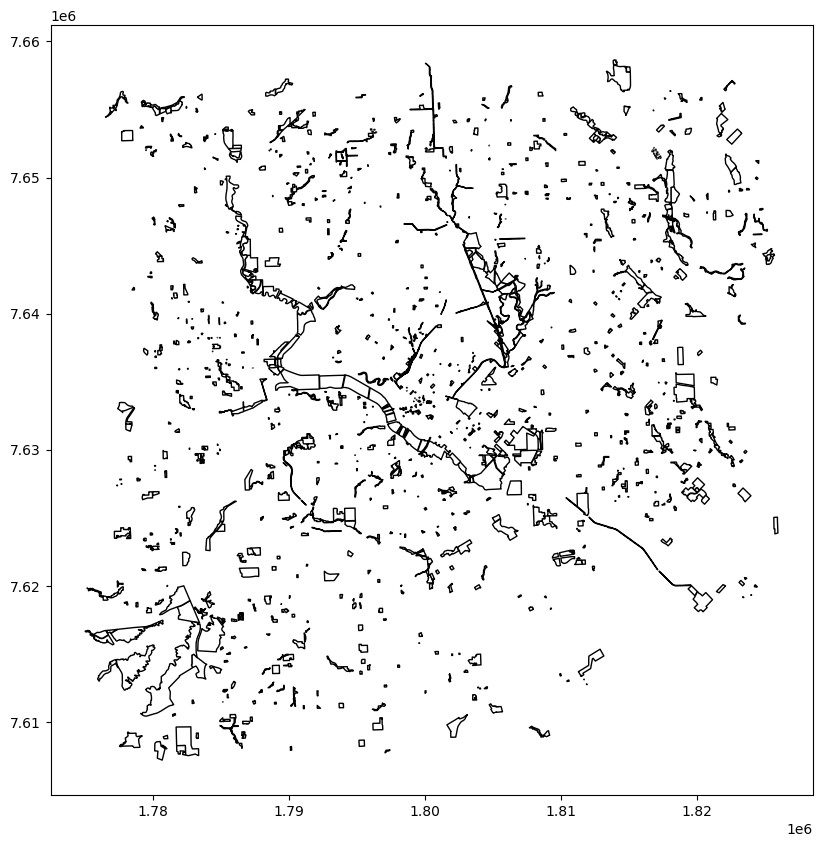

In [16]:
#getting only the boundary of the parks and plotting
dal_parks_projected["boundary"] = dal_parks_projected.boundary
ax = dal_parks_projected.plot(color="white", edgecolor="black", figsize=(10, 10))

In [17]:
dal_parks_projected.head()

,OBJECTID,NAME,OWNER,NOTES,CITY,FEATTYPE,STATUS,SOURCE,SOURCE_YEAR,ShapeSTLength,ShapeSTArea,geometry,in_dallas,boundary
11,12,Twin Star Park,None,E,Rowlett,Local Park,Existing,City of Rowlett,2023,1759.912421,181896.035984,"POLYGON ((1824286.705 7649930.7, 1824341.335 7...",True,"LINESTRING (1824286.705 7649930.7, 1824341.335..."
12,13,Columbia Park,None,F,Rowlett,Local Park,Proposed,City of Rowlett,2023,1200.661102,84838.762961,"POLYGON ((1822292.592 7648935.241, 1822360.091...",True,"LINESTRING (1822292.592 7648935.241, 1822360.0..."
13,14,Paddle Point/N Lakeside,None,E,Rowlett,Local Park,Existing,City of Rowlett,2023,8033.013397,735614.787512,"MULTIPOLYGON (((1823582.29 7647358.52, 1823567...",True,"MULTILINESTRING ((1823582.29 7647358.52, 18235..."
14,15,Kenwood Heights,None,E,Rowlett,Local Park,Existing,City of Rowlett,2023,3385.494851,149958.984225,"POLYGON ((1819471.686 7648638.36, 1819634.792 ...",True,"LINESTRING (1819471.686 7648638.36, 1819634.79..."
15,16,Veterans Memorial Park,None,E,Rowlett,Local Park,Existing,City of Rowlett,2023,882.415201,28145.654443,"POLYGON ((1820720.487 7647472.798, 1820720.737...",True,"LINESTRING (1820720.487 7647472.798, 1820720.7..."


In [18]:
# .intersection() will use the boundaries geometry 
dal_parks_projected = dal_parks_projected.set_geometry('boundary')

points = dal_parks_projected.union_all().intersection(streets_gdf_projected.union_all())

# Switch geometry back to the full shape
dal_parks_projected = dal_parks_projected.set_geometry('geometry')

not a point


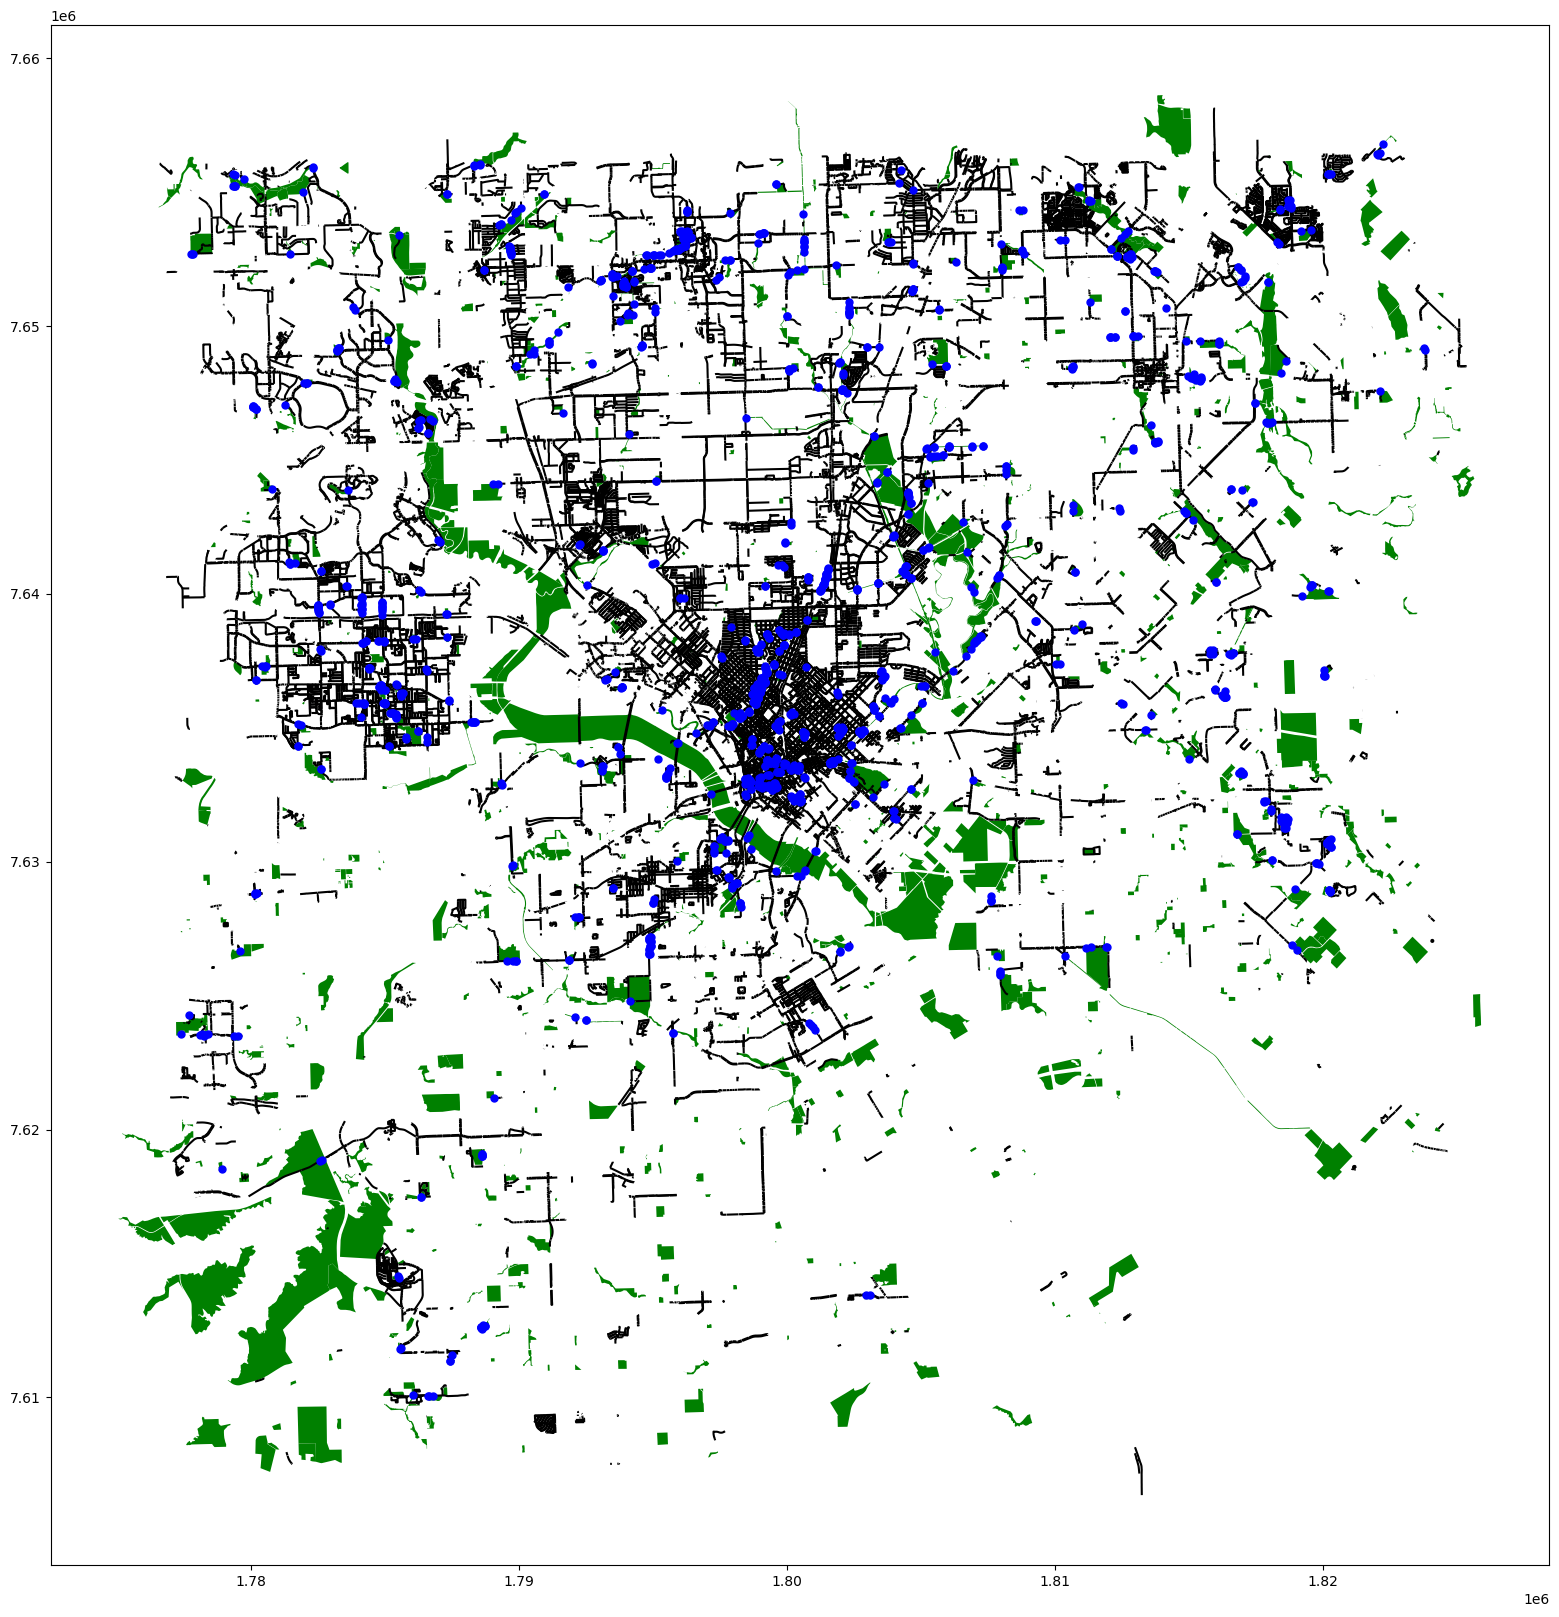

In [19]:
#plot all parks
ax = dal_parks_projected.plot(figsize=(20, 20), color='g')
#plot the streets
streets_gdf_projected.plot(ax=ax, color = 'black')

#plot intersection points of parks and streets
for point in points.geoms:
    if point.geom_type == 'Point':
        # x = [point.x for point in points.geoms]
        # y = [point.y for point in points.geoms]
        ax.plot(*point.xy, color='blue', marker='o', markersize =5, label='Collection Points')
    else:
        print("not a point")
        continue

